# TCGA 

In [48]:
from __future__ import annotations
from pathlib import Path
import pandas as pd
import pyarrow.parquet as pq
import numpy as np

import importlib
import functions
import auxillary_plots
import constants
importlib.reload(constants)
importlib.reload(auxillary_plots)
importlib.reload(functions)
from constants import *


pd.set_option(
    "display.float_format",
    lambda x: f"{x:.2e}" if abs(x) < 0.01 else f"{x:.3f}"
)

PATH_META = PATH_TCGA_META
PATH_COUNTS = PATH_TCGA_COUNTS

print(f'Specificity metric: {SPECIFICITY_METRIC}')
print(f'Specificity threshold: {SPECIFICITY_THR}')
print(f'Figure mode: {FIG_MODE}')

META_COLS = ["Tissue_Organ", "Sample Type", "Project ID", "Cancer_group"]
META_COLS = [c for c in META_COLS if c != TCGA_AGGREGATE_GROUP]

print("PROJ_ROOT =", PROJ_ROOT) 

Specificity metric: Tau
Specificity threshold: 0.8
Figure mode: pdf
PROJ_ROOT = /Users/neuropromotion/Desktop/miRNA/bulk_review


In [49]:
tcga_loader = functions.Load_TCGA_Data(PATH_COUNTS, PATH_META)

In [50]:
linear_df, specificity_tcga_df = tcga_loader.run_pipeline()

Running Tau score, per Tissue_Organ, log2(CPM+1) [log_of_mean]...


In [51]:
lin_df_grouped = tcga_loader.agregate(linear_df)

specificity_tcga_df["tcga_tissues"] = specificity_tcga_df.apply(
    lambda row: functions.get_top_tissues_expression(row, lin_df_grouped, threshold=0), 
    axis=1
)

In [52]:
specificity_tcga_df

,mature_name,Tau_tcga,tcga_tissues
0,hsa-mir-211-3p,0.998,"Skin [0.98], Fallopian tube [0.01], Uterus [0.00]"
1,hsa-mir-367-3p,0.998,"Testis [1.00], Stomach [0.00], Liver–Gallbladd..."
2,hsa-mir-372-5p,0.994,"Testis [0.99], Esophagus [0.01], Lung [0.00]"
3,hsa-mir-216b-3p,0.989,"Pancreas [0.94], Liver–Gallbladder [0.02], Bra..."
4,hsa-mir-302d-3p,0.989,"Testis [1.00], Stomach [0.00], Liver–Gallbladd..."
...,...,...,...
599,hsa-mir-148a-3p,0.108,"Liver–Gallbladder [0.10], Thymus [0.09], Thora..."
600,hsa-mir-361-5p,0.102,"Bone Marrow [0.07], Thorax [0.07], Skin [0.06]"
601,hsa-mir-30d-5p,0.096,"Skin [0.09], Bone Marrow [0.07], Lung [0.07]"
602,hsa-mir-22-3p,0.071,"Liver–Gallbladder [0.08], Adrenal Gland [0.07]..."


In [53]:
specificity_tcga_df.to_csv(TAB_OUT / f'{SPECIFICITY_METRIC}_tcga.csv')

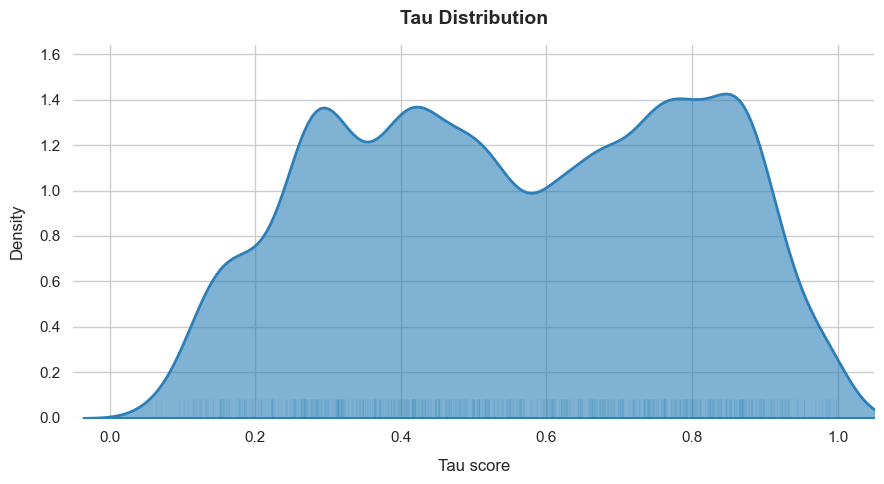

In [54]:
auxillary_plots.plot_specificity_distribution(specificity_tcga_df, 
                            f'{SPECIFICITY_METRIC}_tcga', 
                            save_path=FIG_OUT / f'{SPECIFICITY_METRIC}_distributions_TCGA.{FIG_MODE}')

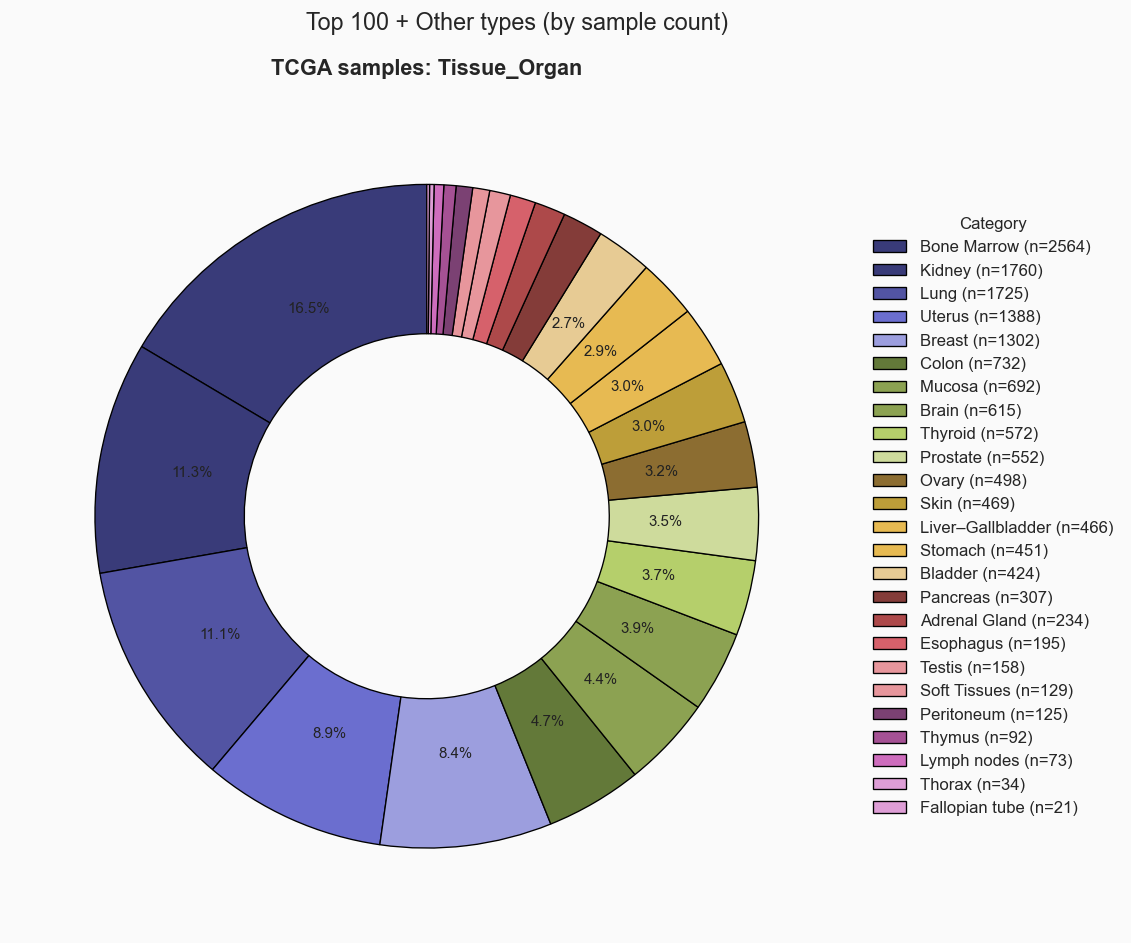

In [55]:
tcga_loader.plot_pie(save_path=FIG_OUT / f'tcga_pie_type.{FIG_MODE}')

In [56]:
de_all, proj_tab, eligible_projects = tcga_loader.tumor_vs_normal()

In [57]:
de_all.head()

,mature_name,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,project_id,n_normal,n_tumor
0,hsa-let-7a-2-3p,7.258,3.728,0.765,4.876,1.08e-06,4.09e-06,CGCI-BLGSP,10,236
1,hsa-let-7a-3p,64.119,0.615,0.330,1.863,0.062,0.103,CGCI-BLGSP,10,236
2,hsa-let-7b-5p,13981.990,1.888,0.341,5.543,2.97e-08,1.26e-07,CGCI-BLGSP,10,236
3,hsa-let-7c-3p,8.144,4.753,0.893,5.325,1.01e-07,4.18e-07,CGCI-BLGSP,10,236
4,hsa-let-7d-5p,824.149,-0.669,0.218,-3.071,2.13e-03,4.78e-03,CGCI-BLGSP,10,236


In [58]:
proj_tab[proj_tab.index.isin(eligible_projects)].to_csv(TAB_OUT / 'eligible_projects.csv')
de_all.to_csv(TAB_OUT / 'de_all.csv')

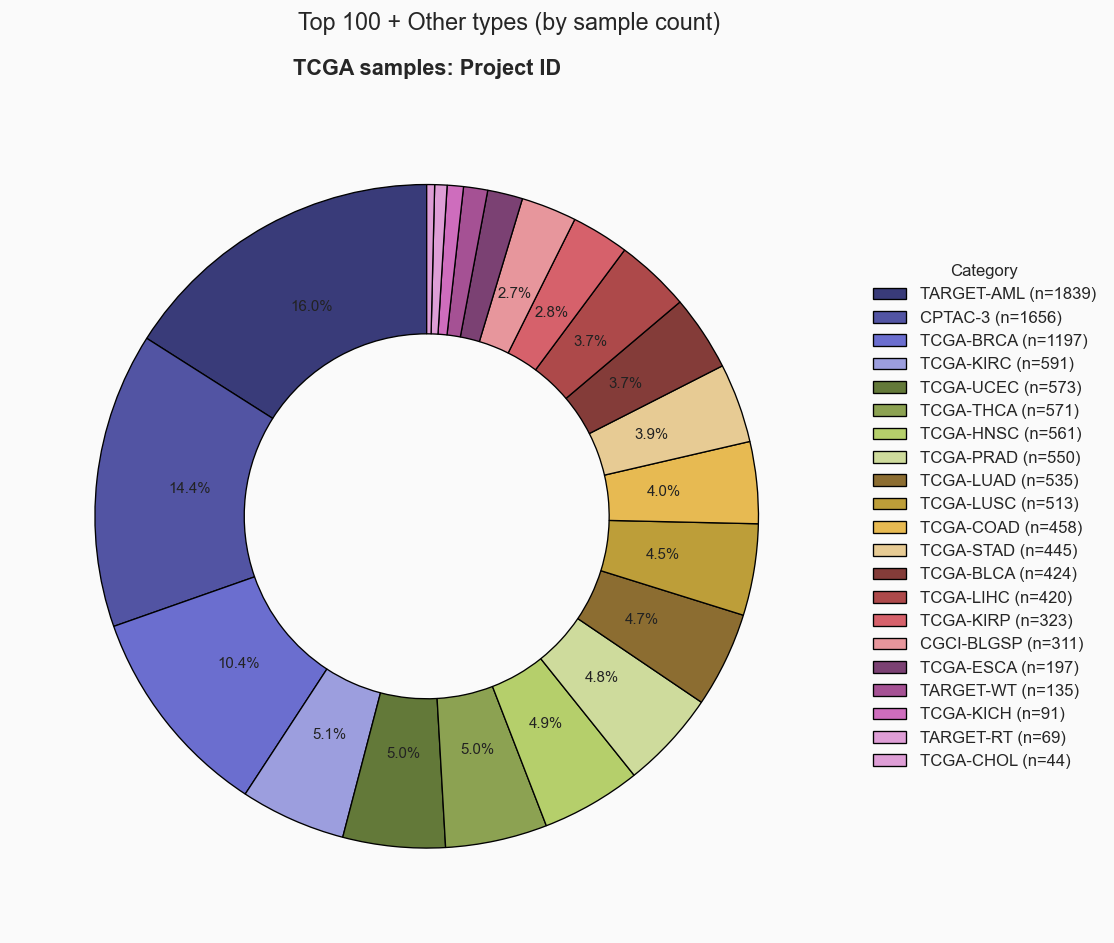

In [59]:
tcga_loader.plot_pie('Project ID', eligible_cols=eligible_projects, save_path=FIG_OUT / f'tcga_pie_project.{FIG_MODE}')

## Binomial test

In [43]:
rows: list[dict] = []
for mir in de_all['mature_name'].unique():
    sub = de_all.loc[de_all["mature_name"] == mir, ["project_id", "log2FoldChange", "padj"]].copy()
    sub["padj"] = pd.to_numeric(sub["padj"], errors="coerce")
    sub["log2FoldChange"] = pd.to_numeric(sub["log2FoldChange"], errors="coerce")

    sig = sub[sub["padj"] < functions.PADJ_THR]
    # уникальные проекты (не число строк в de_all)
    up_proj = sig.loc[sig["log2FoldChange"] > functions.LFC_THR, "project_id"].drop_duplicates()
    down_proj = sig.loc[sig["log2FoldChange"] < -functions.LFC_THR, "project_id"].drop_duplicates()

    # медианы по всем значимым когортам (padj < PADJ_THR); если нет — NaN
    if sig.empty:
        med_lfc = float("nan")
        med_padj = float("nan")
    else:
        med_lfc = float(sig["log2FoldChange"].median())
        med_padj = float(sig["padj"].median())

    nu = int(up_proj.nunique())
    nd = int(down_proj.nunique())
    _, p_excess_up, p_excess_down = functions.binom_pval(nu, nd)

    rows.append(
        {
            "mature_name": mir,
            "n_projects_up": nu,
            "n_projects_down": nd,
            "median_log2fc": med_lfc,
            "median_padj": med_padj,
            "binom_p_up": p_excess_up,
            "binom_p_down": p_excess_down
        }
    )


result = pd.DataFrame(rows)

conditions = [
    (result['binom_p_up'] < BINOM_P_THR),
    (result['binom_p_down'] < BINOM_P_THR)
]
choices = ['UP', 'DOWN']
result['Binomial_result'] = np.select(conditions, choices, default='NS')

result

,mature_name,n_projects_up,n_projects_down,median_log2fc,median_padj,binom_p_up,binom_p_down,Binomial_result
0,hsa-let-7a-2-3p,3,1,-0.455,2.37e-03,0.312,0.938,NS
1,hsa-let-7a-3p,1,0,-0.071,1.56e-04,0.500,1.000,NS
2,hsa-let-7b-5p,2,3,-0.407,2.46e-04,0.812,0.500,NS
3,hsa-let-7c-3p,4,7,-0.567,1.74e-04,0.887,0.274,NS
4,hsa-let-7d-5p,0,1,0.278,1.59e-03,1.000,0.500,NS
...,...,...,...,...,...,...,...,...
597,hsa-mir-367-3p,0,0,NaN,NaN,NaN,NaN,NS
598,hsa-mir-2276-5p,1,0,1.746,6.90e-03,0.500,1.000,NS
599,hsa-mir-520f-5p,0,0,NaN,NaN,NaN,NaN,NS
600,hsa-mir-525-3p,2,0,4.276,1.46e-03,0.250,1.000,NS


In [44]:
result.to_csv(TAB_OUT / 'result_binom_tcga.csv')

## Volcano plots

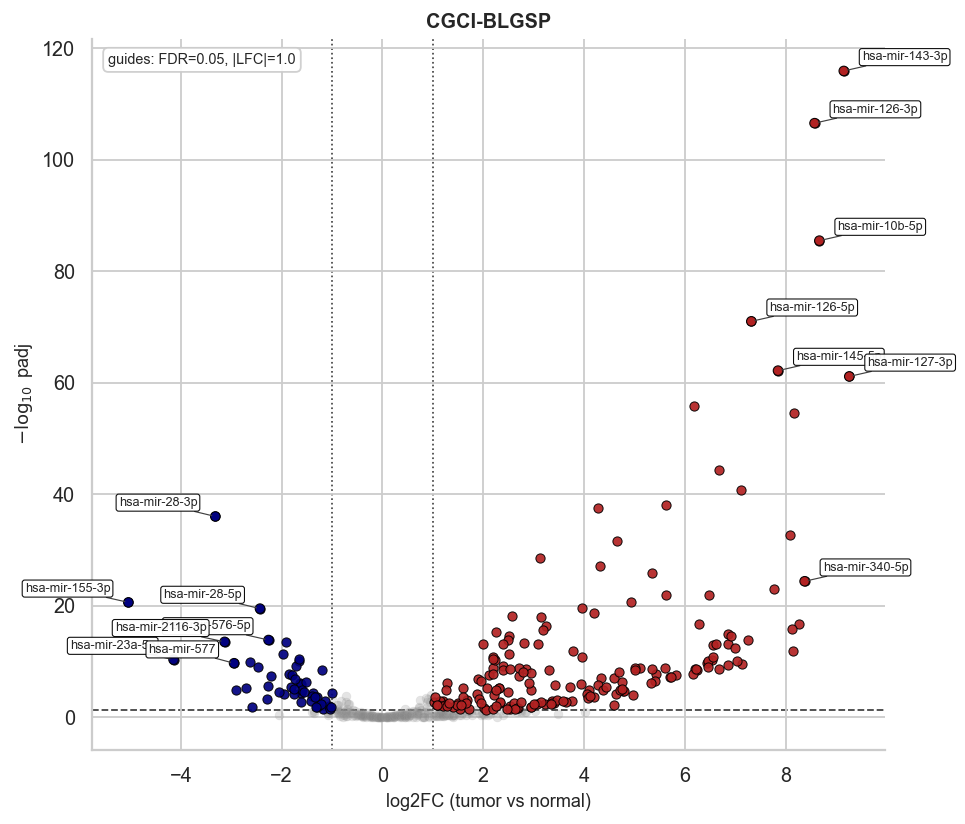

In [45]:
import matplotlib.pyplot as plt

VOLCANO_PROJECT = 'CGCI-BLGSP' #example


_one = de_all[de_all["project_id"] == VOLCANO_PROJECT].copy()
fig, ax = plt.subplots(figsize=(7.6, 6.5), dpi=130)
auxillary_plots.plot_volcano(
    _one,
    ax,
    str(VOLCANO_PROJECT),
    label_top_padj=5,
    label_top_abs_lfc=5,
)
plt.tight_layout()
plt.show()

In [46]:
# Экспорт volcano по всем eligible-проектам в один PDF (отдельная ячейка)
from matplotlib.backends.backend_pdf import PdfPages

VOLCANO_PDF_PATH = FIG_OUT / "volcano_tumor_vs_normal_by_project.pdf"

with PdfPages(VOLCANO_PDF_PATH) as pdf:
    for proj in eligible_projects:
        sub = de_all[de_all["project_id"] == proj]
        if sub.empty:
            continue
        fig, ax = plt.subplots(figsize=(7.6, 6.5), dpi=130)
        auxillary_plots.plot_volcano(
            sub,
            ax,
            str(proj),
            label_top_padj=5,
            label_top_abs_lfc=5,
        )
        plt.tight_layout()
        pdf.savefig(fig, bbox_inches="tight")
        plt.close(fig)

print("PDF:", VOLCANO_PDF_PATH.resolve())

PDF: /Users/neuropromotion/Desktop/miRNA/bulk_review/pipeline_python/figures/volcano_tumor_vs_normal_by_project.pdf
